# EDA 06 - Road Closures + Timetable (Merged)

**Source**: Output of `geo.find_nearby_stations()` + `features.filter_within_time_window()`  
**Reads from**: `data/processed/road_closures_clean.parquet` + `data/processed/darwin_timetable_clean.parquet`  
**Output**: `data/processed/road_timetable_dataset.parquet` - consumed by `rail_delay_prediction.ipynb` for forward prediction

This notebook performs EDA on the road closure + Darwin timetable merged dataset. Unlike the road + train moments dataset (EDA 05), this dataset contains **no actual timestamps** - it is the prediction dataset where planned service times are known but outcomes have not yet been observed. The goal is to understand the scheduled services that fall within the road closure impact zone before the model generates delay forecasts.

---
**Sections**
1. Rebuild the road + timetable dataset from processed parquets  
2. Dataset overview and shape  
3. Coverage comparison: timetable vs analytical (train moments)  
4. Predictor distributions (distance, time since closure)  
5. Categorical distributions (closure type, event type, TOC)  
6. Bivariate relationships (distance x time, correlation matrix)  
7. Scheduled service frequency by hour  
8. Spatial patterns (stations, closure impact on timetable)  
9. Planned time diff distribution within closure window  
10. Save output  


## 0. Setup

In [50]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.insert(0, "..")
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", 40)
os.makedirs("figures/eda_06", exist_ok=True)
os.makedirs("./data/processed", exist_ok=True)
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Rebuild Road + Timetable Dataset

Read the processed parquets saved by EDA 02 (road closures) and EDA 04 (Darwin timetable), then re-run the spatial join and temporal filter using the timetable schedule instead of train moments. This mirrors the pipeline in the main analysis notebook.

In [51]:
from src.geo import find_nearby_stations
from src.features import (
    reshape_timetable_to_schedule,
    merge_schedule_with_closures,
    filter_within_time_window,
)

ROAD_PATH      = "./data/processed/road_closures_clean.parquet"
TIMETABLE_PATH = "./data/processed/darwin_timetable_clean.parquet"
stations_reference_path = "./data/processed/stations_reference.parquet"

if not os.path.exists(ROAD_PATH):
    raise FileNotFoundError("Run EDA 02 first to generate road_closures_clean.parquet")
if not os.path.exists(TIMETABLE_PATH):
    raise FileNotFoundError("Run EDA 04 first to generate darwin_timetable_clean.parquet")

road_df      = pd.read_parquet(ROAD_PATH)
timetable_df = pd.read_parquet(TIMETABLE_PATH)
stations_ref_df = pd.read_parquet(stations_reference_path)

print(f"Road closures:    {len(road_df):,} rows")
print(f"Timetable stops:  {len(timetable_df):,} rows")

Road closures:    296 rows
Timetable stops:  1,898,719 rows


In [53]:
# Spatial join: match each closure to stations within 10-25 km
expanded_road_df = find_nearby_stations(road_df,stations_ref_df, min_km=10, max_km=25)
print(f"Closure-station pairs: {len(expanded_road_df):,}")

Closure-station pairs: 16,361


In [59]:
schedule_df = reshape_timetable_to_schedule(timetable_df, stations_ref_df)
print(f"Schedule rows (after reshape): {len(schedule_df):,}")
schedule_df.head()

Schedule rows (after reshape): 1,898,719


,ssd,tpl,station_code,stanox,timetable_train_id,planned_timestamp,event_type
0,2026-04-10,WATRLMN,NaN,NaN,2S69,2026-04-10 21:22:00,DEPARTURE
1,2026-04-10,WATRLWC,NaN,NaN,2S69,2026-04-10 21:23:30,PASS
2,2026-04-10,VAUXHLM,NaN,NaN,2S69,2026-04-10 21:25:30,ARRIVAL
3,2026-04-10,NINELMJ,NaN,NaN,2S69,2026-04-10 21:28:00,PASS
4,2026-04-10,QTRDBAT,QRB,87216,2S69,2026-04-10 21:29:00,ARRIVAL


In [60]:
# Merge closures with schedule on stanox
merged_schedule = merge_schedule_with_closures(expanded_road_df, schedule_df)
print(f"After merge: {len(merged_schedule):,} rows")

# Temporal filter: 0-60 minutes post-closure
filtered_df = filter_within_time_window(merged_schedule, window_minutes=60)
print(f"After 60-min filter: {len(filtered_df):,} rows")

# Select final columns - no actual_timestamp here (timetable only)
keep_cols = [
    "closure_id", "closure_type", "closure_lat", "closure_lon",
    "validity_status", "cause_type",
    "distance_in_km", "station_name", "stanox", "tpl",
    "closure_start_time", "planned_timestamp",
    "planned_time_diff", "event_type",
]
filtered_df = filtered_df[[c for c in keep_cols if c in filtered_df.columns]].copy()
filtered_df["planned_timestamp"] = pd.to_datetime(filtered_df["planned_timestamp"])

# Interaction feature
filtered_df["distance_time_interaction"] = (
    filtered_df["distance_in_km"] * filtered_df["planned_time_diff"]
)

print(f"\nFinal road + timetable dataset: {len(filtered_df):,} rows")
filtered_df.head()

After merge: 2,388,490 rows
After 60-min filter: 100,069 rows

Final road + timetable dataset: 100,069 rows


,closure_id,closure_type,closure_lat,closure_lon,validity_status,cause_type,distance_in_km,station_name,stanox,tpl,closure_start_time,planned_timestamp,planned_time_diff,event_type,distance_time_interaction
0,481398,planned,52.241032,0.056728,planned,roadMaintenance,21.561992,Dullingham,47006,DULNGHM,2026-04-11 19:00:00,2026-04-11 20:00:00,60.0,ARRIVAL,1293.719539
25,481398,planned,52.241032,0.056728,planned,roadMaintenance,21.561992,Dullingham,47006,DULNGHM,2026-04-11 19:00:00,2026-04-11 19:21:30,21.5,ARRIVAL,463.582835
61,481398,planned,52.241032,0.056728,planned,roadMaintenance,21.974512,Ely,46273,ELYY,2026-04-11 19:00:00,2026-04-11 19:16:00,16.0,ARRIVAL,351.592191
62,481398,planned,52.241032,0.056728,planned,roadMaintenance,21.974512,Ely,46273,ELYY,2026-04-11 19:00:00,2026-04-11 19:51:00,51.0,ARRIVAL,1120.700108
74,481398,planned,52.241032,0.056728,planned,roadMaintenance,21.974512,Ely,46273,ELYY,2026-04-11 19:00:00,2026-04-11 19:14:00,14.0,ARRIVAL,307.643167


## 2. Dataset Overview

In [61]:
filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100069 entries, 0 to 2388458
Data columns (total 15 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   closure_id                 100069 non-null  object        
 1   closure_type               100069 non-null  object        
 2   closure_lat                100069 non-null  float64       
 3   closure_lon                100069 non-null  float64       
 4   validity_status            100069 non-null  object        
 5   cause_type                 100069 non-null  object        
 6   distance_in_km             100069 non-null  float64       
 7   station_name               100069 non-null  object        
 8   stanox                     100069 non-null  object        
 9   tpl                        100069 non-null  object        
 10  closure_start_time         100069 non-null  datetime64[ns]
 11  planned_timestamp          100069 non-null  datetime64[n

In [62]:
print("=" * 70)
print("DATASET SUMMARY")
print("=" * 70)
print(f"Total rows:              {len(filtered_df):,}")
print(f"Unique stations:         {filtered_df['station_name'].nunique():,}")
print(f"Unique closures:         {filtered_df['closure_id'].nunique():,}")
print(f"Date range (planned):    {filtered_df['planned_timestamp'].min()} - {filtered_df['planned_timestamp'].max()}")
print()
print("By closure type:")
print(filtered_df["closure_type"].value_counts().to_string())
print()
print("By event type:")
print(filtered_df["event_type"].value_counts().to_string())

DATASET SUMMARY
Total rows:              100,069
Unique stations:         1,467
Unique closures:         190
Date range (planned):    2026-04-09 19:08:00 - 2026-04-12 23:00:00

By closure type:
closure_type
unplanned    56846
planned      43223

By event type:
event_type
ARRIVAL      75597
PASS         17987
DEPARTURE     6485


## 3. Coverage Comparison: Timetable vs Train Moments

This section compares how many rows each data source contributes after the same spatial and temporal filtering. The difference reveals how many scheduled services lack corresponding train movement records, these are the observations that the model predicts for but cannot validate directly.

In [63]:
MOMENTS_PATH = "./data/processed/road_train_moments_dataset.parquet"

if os.path.exists(MOMENTS_PATH):
    moments_df = pd.read_parquet(MOMENTS_PATH)
    print(f"{'Source':<30} {'Rows':>10} {'Unique stations':>17} {'Unique closures':>17}")
    print("-" * 80)
    print(f"{'Road + Train Moments (EDA 05)':<30} {len(moments_df):>10,} {moments_df['station_name'].nunique():>17,} {moments_df['closure_id'].nunique():>17,}")
    print(f"{'Road + Timetable (this NB)':<30} {len(filtered_df):>10,} {filtered_df['station_name'].nunique():>17,} {filtered_df['closure_id'].nunique():>17,}")
    ratio = len(filtered_df) / len(moments_df)
    print(f"\nTimetable is {ratio:.1f}x larger than train moments dataset after filtering")
else:
    print("analytical_dataset.parquet not found - run EDA 05 first for comparison")

Source                               Rows   Unique stations   Unique closures
--------------------------------------------------------------------------------
Road + Train Moments (EDA 05)       5,446               854               126
Road + Timetable (this NB)        100,069             1,467               190

Timetable is 18.4x larger than train moments dataset after filtering


In [64]:
if os.path.exists(MOMENTS_PATH):
    moments_df = pd.read_parquet(MOMENTS_PATH)

    # Station overlap
    t_stations = set(filtered_df["station_name"].dropna())
    m_stations = set(moments_df["station_name"].dropna())
    overlap    = t_stations & m_stations
    timetable_only = t_stations - m_stations
    moments_only   = m_stations - t_stations

    print(f"Stations in timetable only:    {len(timetable_only):,}")
    print(f"Stations in both datasets:     {len(overlap):,}")
    print(f"Stations in train moments only:{len(moments_only):,}")

    # Closure overlap
    t_closures = set(filtered_df["closure_id"].dropna())
    m_closures = set(moments_df["closure_id"].dropna())
    print(f"\nClosures in timetable only:    {len(t_closures - m_closures):,}")
    print(f"Closures in both datasets:     {len(t_closures & m_closures):,}")
    print(f"Closures in moments only:      {len(m_closures - t_closures):,}")

Stations in timetable only:    621
Stations in both datasets:     846
Stations in train moments only:8

Closures in timetable only:    64
Closures in both datasets:     126
Closures in moments only:      0


## 4. Predictor Distributions

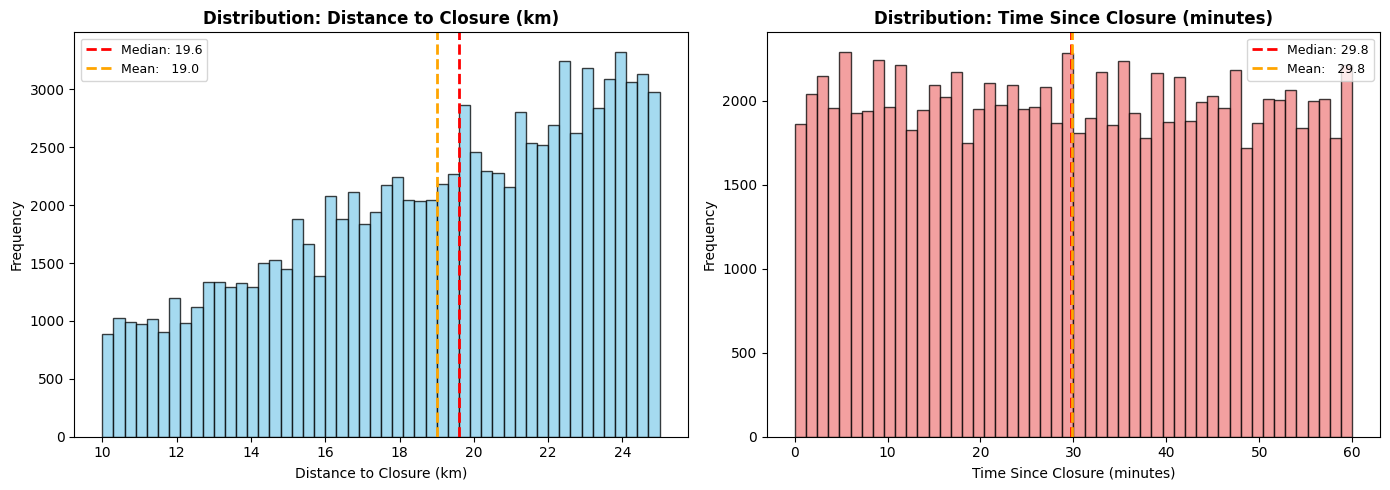


distance_in_km: mean=19.01, median=19.61, std=4.07, min=10.00, max=25.00

planned_time_diff: mean=29.85, median=29.77, std=17.33, min=0.02, max=60.00


In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, color, label in [
    (axes[0], "distance_in_km",   "skyblue",    "Distance to Closure (km)"),
    (axes[1], "planned_time_diff","lightcoral", "Time Since Closure (minutes)")
]:
    s = filtered_df[col]
    ax.hist(s, bins=50, edgecolor="black", alpha=0.75, color=color)
    ax.axvline(s.median(), color="red",    linestyle="--", lw=2, label=f"Median: {s.median():.1f}")
    ax.axvline(s.mean(),   color="orange", linestyle="--", lw=2, label=f"Mean:   {s.mean():.1f}")
    ax.set_xlabel(label)
    ax.set_ylabel("Frequency")
    ax.set_title(f"Distribution: {label}", fontweight="bold")
    ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("figures/eda_06/predictor_distributions.png", dpi=200, bbox_inches="tight")
plt.show()

for col in ["distance_in_km", "planned_time_diff"]:
    s = filtered_df[col]
    print(f"\n{col}: mean={s.mean():.2f}, median={s.median():.2f}, "
          f"std={s.std():.2f}, min={s.min():.2f}, max={s.max():.2f}")

## 5. Categorical Distributions

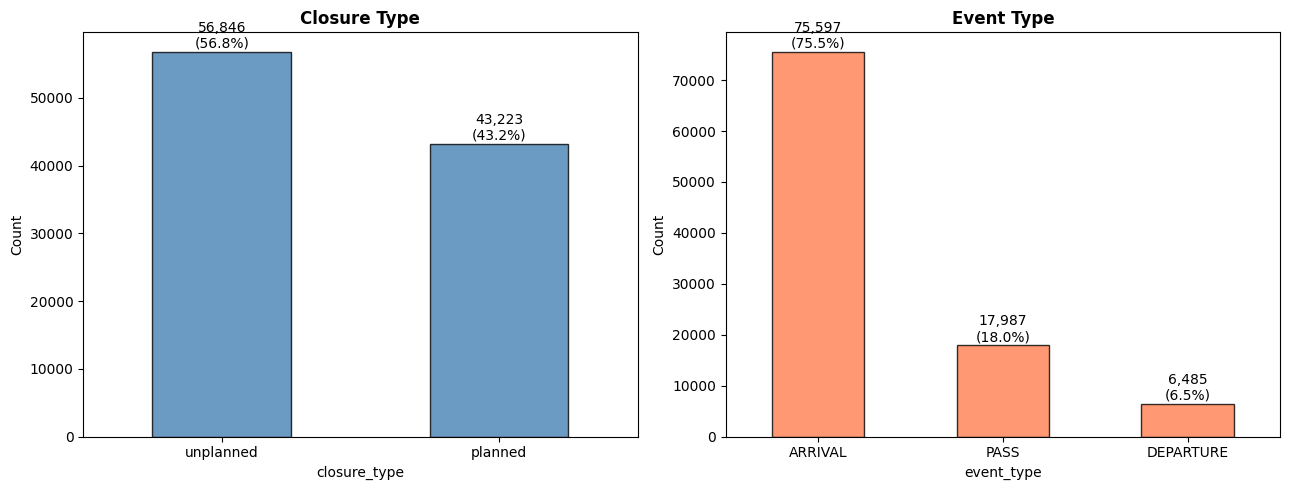

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ct = filtered_df["closure_type"].value_counts()
ct.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black", alpha=0.8)
axes[0].set_title("Closure Type", fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)
for i, v in enumerate(ct.values):
    axes[0].text(i, v + max(ct)*0.01, f"{v:,}\n({v/len(filtered_df)*100:.1f}%)",
                 ha="center", fontsize=10)

et = filtered_df["event_type"].value_counts()
et.plot(kind="bar", ax=axes[1], color="coral", edgecolor="black", alpha=0.8)
axes[1].set_title("Event Type", fontweight="bold")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)
for i, v in enumerate(et.values):
    axes[1].text(i, v + max(et)*0.01, f"{v:,}\n({v/len(filtered_df)*100:.1f}%)",
                 ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("figures/eda_06/categorical_distributions.png", dpi=200, bbox_inches="tight")
plt.show()

In [67]:
# Closure type x event type cross-tabulation
ct_et = pd.crosstab(filtered_df["closure_type"], filtered_df["event_type"],
                    margins=True, margins_name="Total")
print("Closure type x Event type:")
print(ct_et.to_string())

Closure type x Event type:
event_type    ARRIVAL  DEPARTURE   PASS   Total
closure_type                                   
planned         33658       2961   6604   43223
unplanned       41939       3524  11383   56846
Total           75597       6485  17987  100069


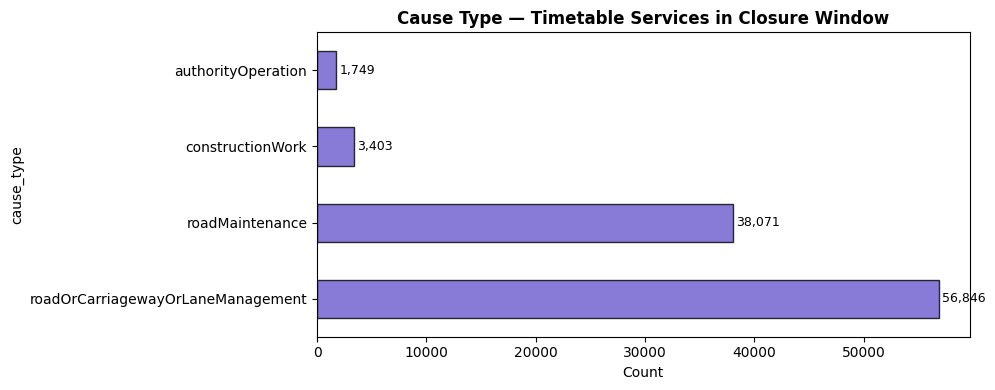

In [68]:
# Cause type distribution
if "cause_type" in filtered_df.columns:
    cause = filtered_df["cause_type"].value_counts()
    plt.figure(figsize=(10, 4))
    cause.plot(kind="barh", color="slateblue", edgecolor="black", alpha=0.8)
    plt.xlabel("Count")
    plt.title("Cause Type - Timetable Services in Closure Window", fontweight="bold")
    for i, v in enumerate(cause.values):
        plt.text(v + max(cause)*0.005, i, f"{v:,}", va="center", fontsize=9)
    plt.tight_layout()
    plt.savefig("figures/eda_06/cause_type.png", dpi=200, bbox_inches="tight")
    plt.show()

## 6. Bivariate Relationships

There is no delay column in this dataset (it is the prediction dataset). Instead, bivariate analysis examines how predictors relate to each other, and how service density varies across the spatial-temporal space.

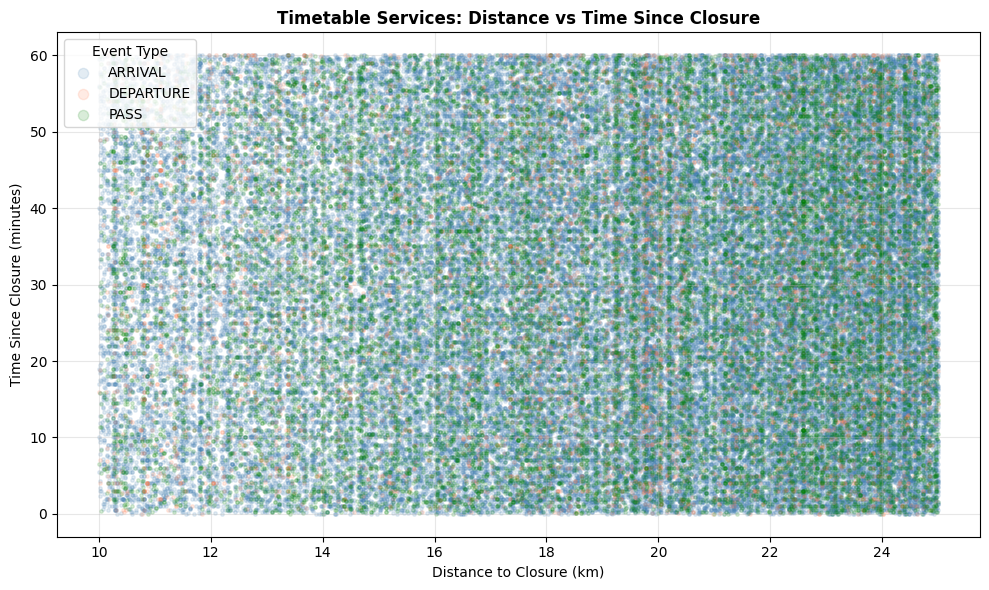

In [69]:
# Scatter: distance vs planned_time_diff coloured by event type
fig, ax = plt.subplots(figsize=(10, 6))
colors = {"ARRIVAL": "steelblue", "DEPARTURE": "coral", "PASS": "green"}
for etype, grp in filtered_df.groupby("event_type"):
    ax.scatter(grp["distance_in_km"], grp["planned_time_diff"],
               alpha=0.15, s=6, label=etype, color=colors.get(etype, "grey"))
ax.set_xlabel("Distance to Closure (km)")
ax.set_ylabel("Time Since Closure (minutes)")
ax.set_title("Timetable Services: Distance vs Time Since Closure", fontweight="bold")
ax.legend(title="Event Type", markerscale=3)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/eda_06/scatter_distance_time.png", dpi=200, bbox_inches="tight")
plt.show()

C:\Users\home\AppData\Local\Temp\ipykernel_17848\331773891.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = hm.pivot_table(values="planned_timestamp", index="dist_bin",


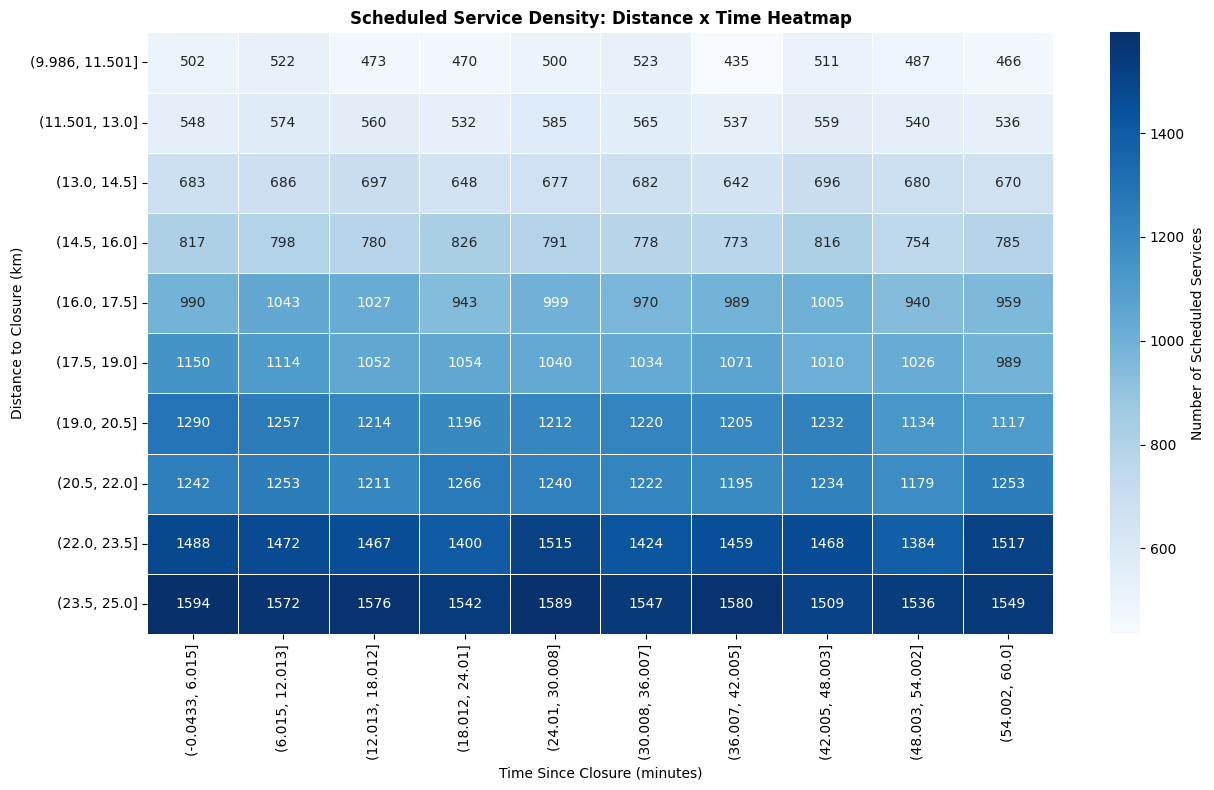

In [70]:
# Service density heatmap: count of scheduled services per distance x time bin
hm = filtered_df.copy()
hm["dist_bin"] = pd.cut(hm["distance_in_km"],   bins=10)
hm["time_bin"] = pd.cut(hm["planned_time_diff"], bins=10)
pivot = hm.pivot_table(values="planned_timestamp", index="dist_bin",
                       columns="time_bin", aggfunc="count")

plt.figure(figsize=(13, 8))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="Blues",
            cbar_kws={"label": "Number of Scheduled Services"}, linewidths=0.5)
plt.xlabel("Time Since Closure (minutes)")
plt.ylabel("Distance to Closure (km)")
plt.title("Scheduled Service Density: Distance x Time Heatmap", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/eda_06/heatmap_service_density.png", dpi=200, bbox_inches="tight")
plt.show()

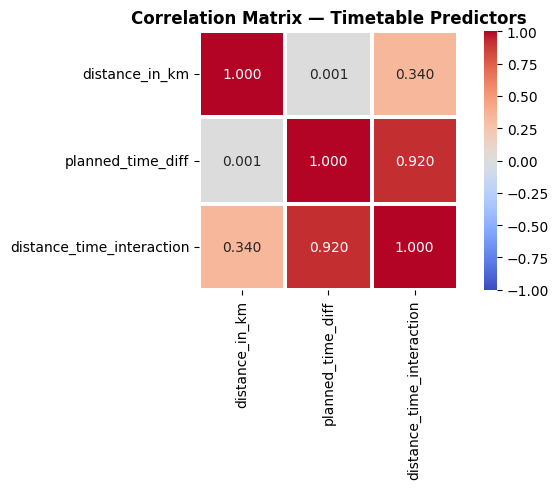

                           distance_in_km  planned_time_diff  distance_time_interaction
distance_in_km                   1.000000           0.000791                   0.340189
planned_time_diff                0.000791           1.000000                   0.919876
distance_time_interaction        0.340189           0.919876                   1.000000


In [71]:
# Correlation matrix of numeric predictors
numeric_cols = ["distance_in_km", "planned_time_diff", "distance_time_interaction"]
corr_matrix  = filtered_df[numeric_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="coolwarm", center=0,
            square=True, linewidths=1.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix - Timetable Predictors", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/eda_06/correlation_matrix.png", dpi=200, bbox_inches="tight")
plt.show()
print(corr_matrix.to_string())

## 7. Scheduled Service Frequency by Hour

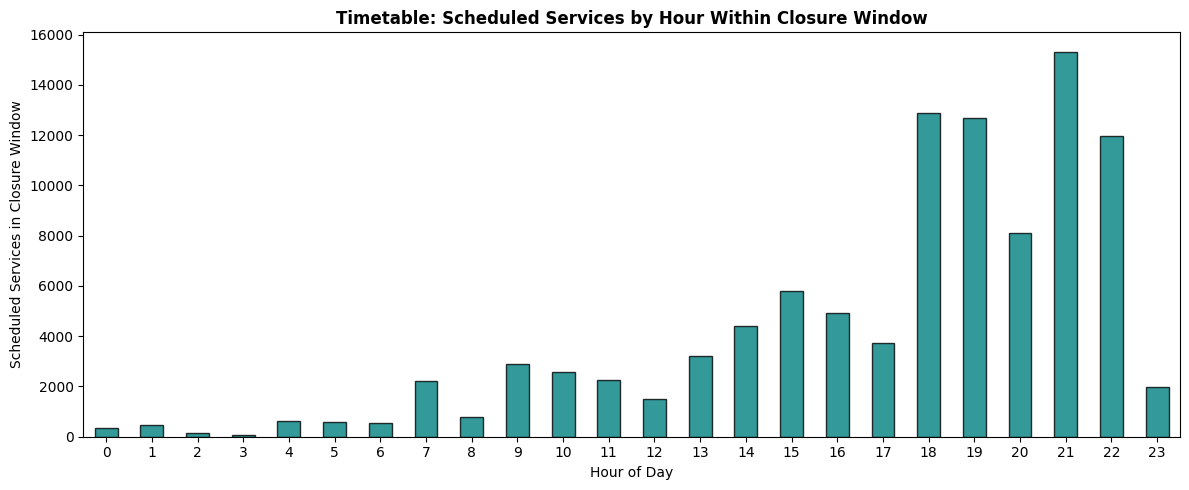

Scheduled services by hour:
hour
0       330
1       472
2       140
3        69
4       614
5       579
6       563
7      2235
8       781
9      2886
10     2576
11     2242
12     1508
13     3217
14     4415
15     5814
16     4911
17     3729
18    12892
19    12704
20     8096
21    15328
22    11973
23     1995


In [72]:
filtered_df["hour"] = filtered_df["planned_timestamp"].dt.hour
hour_counts = filtered_df["hour"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
hour_counts.plot(kind="bar", color="teal", edgecolor="black", alpha=0.8)
plt.xlabel("Hour of Day")
plt.ylabel("Scheduled Services in Closure Window")
plt.title("Timetable: Scheduled Services by Hour Within Closure Window", fontweight="bold")
plt.xticks(range(len(hour_counts)), hour_counts.index, rotation=0)
plt.tight_layout()
plt.savefig("figures/eda_06/scheduled_by_hour.png", dpi=200, bbox_inches="tight")
plt.show()

print("Scheduled services by hour:")
print(hour_counts.to_string())

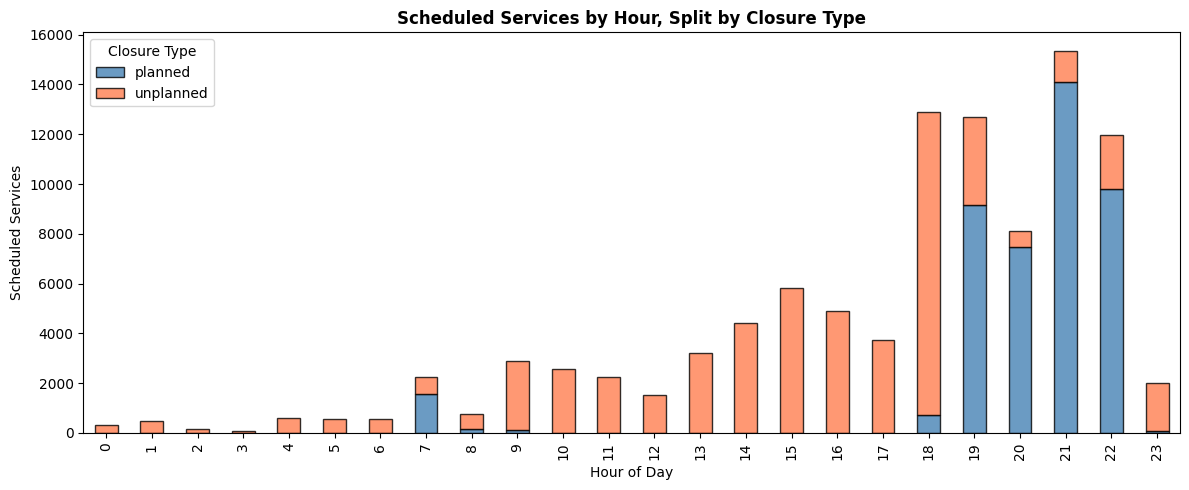

In [73]:
# Hour x closure type breakdown
hour_ct = filtered_df.groupby(["hour", "closure_type"]).size().unstack(fill_value=0)
hour_ct.plot(kind="bar", stacked=True, figsize=(12, 5),
             color=["steelblue", "coral"], edgecolor="black", alpha=0.8)
plt.xlabel("Hour of Day")
plt.ylabel("Scheduled Services")
plt.title("Scheduled Services by Hour, Split by Closure Type", fontweight="bold")
plt.legend(title="Closure Type")
plt.tight_layout()
plt.savefig("figures/eda_06/scheduled_by_hour_closure_type.png", dpi=200, bbox_inches="tight")
plt.show()

## 8. Spatial Patterns

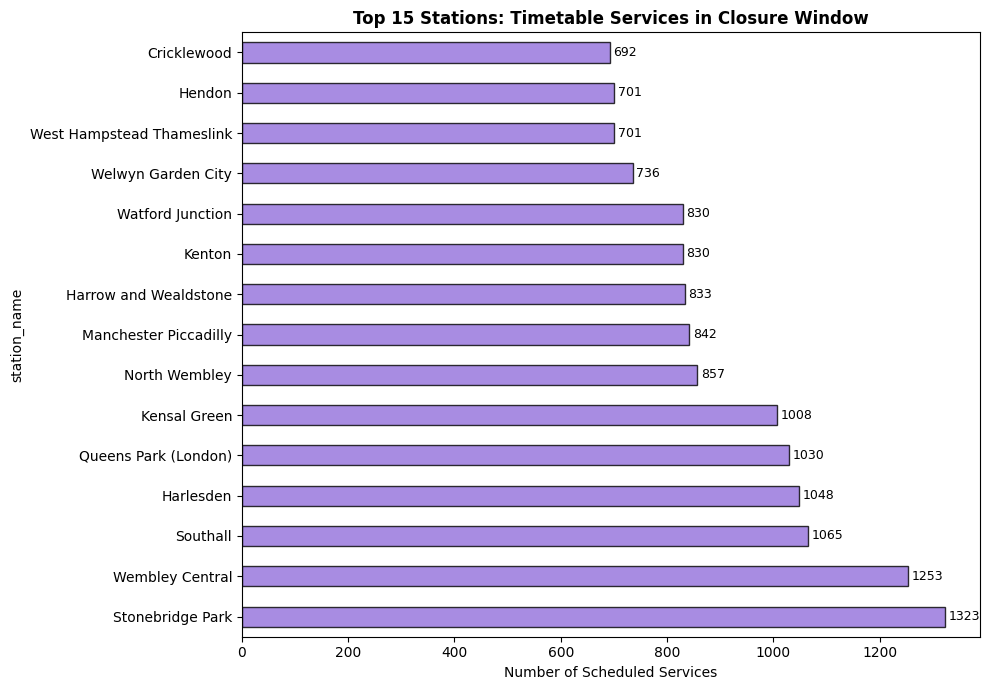

Top 15 stations: 13,749 rows (13.7% of total)


In [74]:
top_stations = filtered_df["station_name"].value_counts().head(15)
plt.figure(figsize=(10, 7))
top_stations.plot(kind="barh", color="mediumpurple", edgecolor="black", alpha=0.8)
plt.xlabel("Number of Scheduled Services")
plt.title("Top 15 Stations: Timetable Services in Closure Window", fontweight="bold")
for i, v in enumerate(top_stations.values):
    plt.text(v + max(top_stations)*0.005, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.savefig("figures/eda_06/top_stations.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Top 15 stations: {top_stations.sum():,} rows ({top_stations.sum()/len(filtered_df)*100:.1f}% of total)")

In [75]:
# Compare top stations: timetable vs train moments
if os.path.exists(MOMENTS_PATH):
    moments_df = pd.read_parquet(MOMENTS_PATH)
    top_t = filtered_df["station_name"].value_counts().head(15).rename("timetable")
    top_m = moments_df["station_name"].value_counts().reindex(top_t.index).rename("moments")
    comparison = pd.concat([top_t, top_m], axis=1).fillna(0).astype(int)
    print("Top 15 stations: timetable vs train moments row counts")
    print(comparison.to_string())

Top 15 stations: timetable vs train moments row counts
                           timetable  moments
station_name                                 
Stonebridge Park                1323       26
Wembley Central                 1253       63
Southall                        1065       70
Harlesden                       1048       42
Queens Park (London)            1030       38
Kensal Green                    1008       30
North Wembley                    857       32
Manchester Piccadilly            842       31
Harrow and Wealdstone            833       54
Kenton                           830       25
Watford Junction                 830       45
Welwyn Garden City               736       18
West Hampstead Thameslink        701       37
Hendon                           701       40
Cricklewood                      692       21


Unique closures affecting timetable: 190
Mean services per closure:           526.7
Median services per closure:         186.5
Max services per closure:            4,486


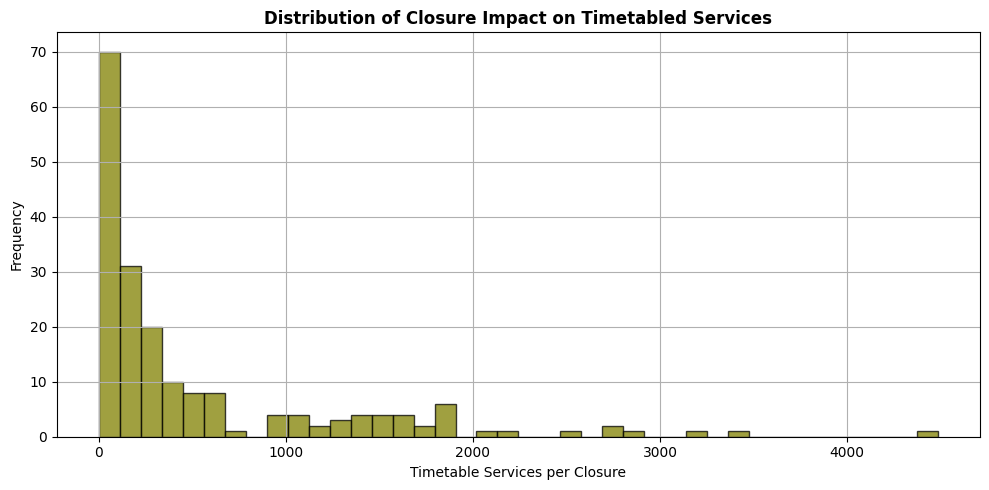

In [76]:
# Closure impact: how many timetable services does each closure affect?
closure_impact = filtered_df.groupby("closure_id").size().sort_values(ascending=False)
print(f"Unique closures affecting timetable: {len(closure_impact):,}")
print(f"Mean services per closure:           {closure_impact.mean():.1f}")
print(f"Median services per closure:         {closure_impact.median():.1f}")
print(f"Max services per closure:            {closure_impact.max():,}")

plt.figure(figsize=(10, 5))
closure_impact.hist(bins=40, edgecolor="black", alpha=0.75, color="olive")
plt.xlabel("Timetable Services per Closure")
plt.ylabel("Frequency")
plt.title("Distribution of Closure Impact on Timetabled Services", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/eda_06/closure_impact.png", dpi=200, bbox_inches="tight")
plt.show()

## 9. Planned Time Diff Distribution Within Closure Window

Understanding how timetable services are distributed across the 0-60 minute window informs whether the temporal filter captures a representative slice of scheduled operations or is dominated by services at particular intervals.

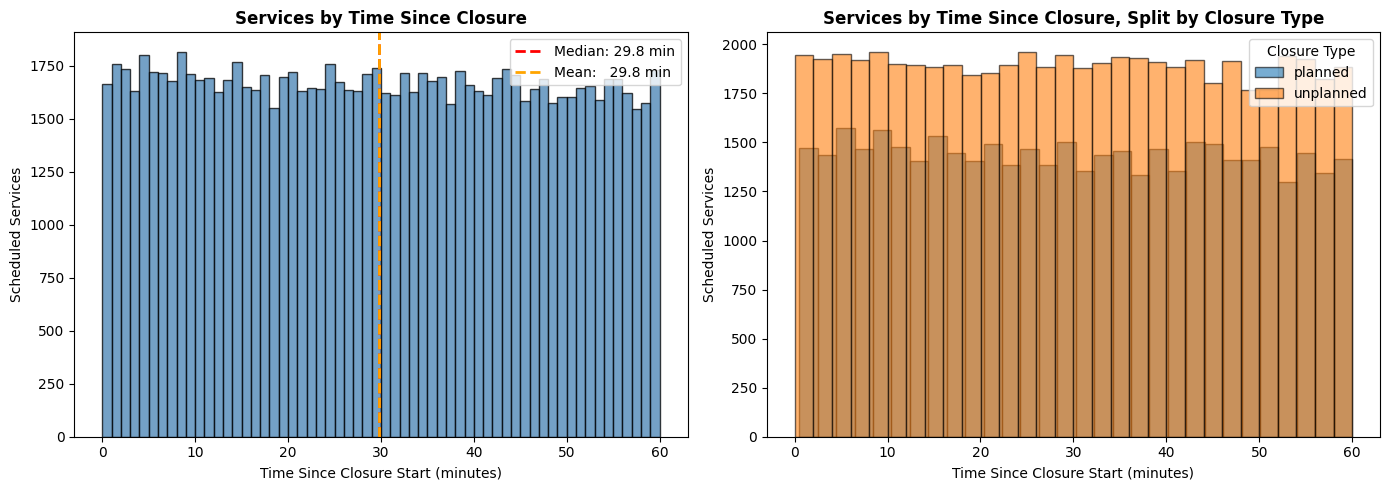

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
s = filtered_df["planned_time_diff"]
axes[0].hist(s, bins=60, edgecolor="black", alpha=0.75, color="steelblue")
axes[0].axvline(s.median(), color="red",    linestyle="--", lw=2, label=f"Median: {s.median():.1f} min")
axes[0].axvline(s.mean(),   color="orange", linestyle="--", lw=2, label=f"Mean:   {s.mean():.1f} min")
axes[0].set_xlabel("Time Since Closure Start (minutes)")
axes[0].set_ylabel("Scheduled Services")
axes[0].set_title("Services by Time Since Closure", fontweight="bold")
axes[0].legend()

# By closure type
for ctype, grp in filtered_df.groupby("closure_type"):
    axes[1].hist(grp["planned_time_diff"], bins=30, alpha=0.6,
                 edgecolor="black", label=ctype)
axes[1].set_xlabel("Time Since Closure Start (minutes)")
axes[1].set_ylabel("Scheduled Services")
axes[1].set_title("Services by Time Since Closure, Split by Closure Type", fontweight="bold")
axes[1].legend(title="Closure Type")

plt.tight_layout()
plt.savefig("figures/eda_06/planned_time_diff_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

In [78]:
# 10-minute bucket analysis
filtered_df["time_bucket"] = pd.cut(
    filtered_df["planned_time_diff"],
    bins=[0, 10, 20, 30, 40, 50, 60],
    labels=["0-10", "10-20", "20-30", "30-40", "40-50", "50-60"]
)
bucket_ct = filtered_df.groupby(["time_bucket", "closure_type"]).size().unstack(fill_value=0)
print("Scheduled services by 10-minute bucket and closure type:")
print(bucket_ct.to_string())
bucket_ct["Total"] = bucket_ct.sum(axis=1)
print(f"\nProportion per bucket:\n{(bucket_ct['Total'] / bucket_ct['Total'].sum() * 100).round(1).to_string()}")

Scheduled services by 10-minute bucket and closure type:
closure_type  planned  unplanned
time_bucket                     
0-10             7518       9702
10-20            7263       9418
20-30            7232       9544
30-40            7054       9558
40-50            7167       9287
50-60            6989       9337

Proportion per bucket:
time_bucket
0-10     17.2
10-20    16.7
20-30    16.8
30-40    16.6
40-50    16.4
50-60    16.3


C:\Users\home\AppData\Local\Temp\ipykernel_17848\966308671.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_ct = filtered_df.groupby(["time_bucket", "closure_type"]).size().unstack(fill_value=0)


## 10. Save Output

In [79]:
filtered_df.to_parquet("./data/processed/road_timetable_dataset.parquet", index=False)
print(f"Saved road + timetable dataset: {len(filtered_df):,} rows")
print("Path: data/processed/road_timetable_dataset.parquet")
print()
print("Column summary:")
filtered_df.info()

Saved road + timetable dataset: 100,069 rows
Path: data/processed/road_timetable_dataset.parquet

Column summary:
<class 'pandas.core.frame.DataFrame'>
Index: 100069 entries, 0 to 2388458
Data columns (total 17 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   closure_id                 100069 non-null  object        
 1   closure_type               100069 non-null  object        
 2   closure_lat                100069 non-null  float64       
 3   closure_lon                100069 non-null  float64       
 4   validity_status            100069 non-null  object        
 5   cause_type                 100069 non-null  object        
 6   distance_in_km             100069 non-null  float64       
 7   station_name               100069 non-null  object        
 8   stanox                     100069 non-null  object        
 9   tpl                        100069 non-null  object        
 10  closur